# Vidarbha — CHF Composite Index Backtest & Nowcast (v7)

## Key changes from v5/v6
1. **Composite Crop Health Factor (CHF)** replaces binary rule-based triggers — entropy-weighted combination of satellite features (per [Murthy et al. 2021, West Bengal PMFBY](https://doi.org/10.1080/19475705.2021.2025155))
2. **Phenological sub-windows** — separate features for Jun-Jul / Aug-Sep / Oct instead of fixed kharif average (per [Afshar et al. 2021, *Remote Sensing*](https://doi.org/10.3390/rs13050924))
3. **Yield-calibrated thresholds** — strike/exit set against APY yield anomalies, not internal percentiles
4. **FAPAR added** — MODIS MCD15A3H photosynthetic activity, a more direct crop productivity proxy than NDVI alone

## Changes from v4 (see `Trigger_Threshold_Review_Notes.md`)

1. **IMD standards** replace arbitrary p70 for `cumRain_mm` (>120% LPA) and `heavy_rain_days` (>64.5mm/day IMD definition)
2. **VHI relabelled** as internal percentile — not Kogan's international scale (season-mean aggregation prevents direct comparison)
3. **Heat trigger dropped** — `gdd_surplus` (CV=37%) and `lst_anom_augsep` (CV=832%) are statistically unstable with 4 years of baseline
4. **2-of-3 AND logic** within each peril replaces pure OR (fixes the 75% fire rate problem)
5. **WBCIS tiered payouts** replace binary triggers — Strike/Exit structure per the official Indian weather-index insurance guidelines
6. **APY yield validation** — 24 years of district-level cotton/soybean yields cross-checked against satellite signals
7. **EOS-06 ISRO NDVI** added to nowcast section

## Conceptual framing

```
Satellite data → IMD/agronomic thresholds → Tiered payout (WBCIS formula) ────┐
                                                                                ▼
PMFBY payouts ──────────────────────────────────────────────────→  Comparison benchmark
APY district yields ───────────────────────────────────────────→  Independent validation
```

## Trigger architecture (revised)
```
DROUGHT : ≥2 of {VHI < p30, drySpellDays > p70, dry_spell_julaug > p70}
FLOOD   : ≥2 of {cumRain > 120% LPA, heavy_rain_days ≥ 3 (IMD heavy-rain count), sm_wet_days > p70}
─────────────────────────────────────────────────────────────────
PAYOUT  : ANY peril fires → tiered payout (Strike1/Strike2/Exit per WBCIS)
```
Heat trigger removed from v5 — will return when baseline extends to 10+ years.

## Parts
- **A** — APY yield validation: does our satellite signal match actual crop outcomes?
- **B** — Satellite distributions with revised thresholds
- **C** — Trigger implementation (2-of-3 AND, tiered payout)
- **D** — Backtest vs PMFBY
- **E** — Nowcast 2025 (with EOS-06 ISRO data)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr, entropy as scipy_entropy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
OUT = Path('./vidarbha_outputs')
OUT.mkdir(exist_ok=True)

BACKTEST_YEARS = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
NOWCAST_YEAR   = 2025

DISTRICT_LPA = {
    'Yavatmal':   950.0,
    'Amravati':   850.0,
    'Chandrapur': 1100.0,
    'Wardha':     860.0,
}

SUM_INSURED_PER_HA = 40000
PMFBY_LOSS_THRESHOLD = 0.10

print('v7 config loaded.')

v7 config loaded.


In [2]:
# ── Load & merge all feature sources ──────────────────────────────────────────
base = pd.read_csv('data/processed/all_districts_final_features.csv')
chf_raw = pd.read_csv('data/processed/chf_features_all_districts.csv')

df = base.merge(
    chf_raw.drop(columns=['lat','lon'], errors='ignore'),
    on=['district','taluka','revenue_circle','year'],
    how='left'
)
df['revenue_circle'] = df['revenue_circle'].str.strip()

# Load APY
apy_raw = pd.read_csv('data/processed/apy_district_yields.csv')
apy_raw = apy_raw.dropna(subset=['cotton_lint_yield_kg_ha','soybean_yield_kg_ha'], how='all')

# Compute per-district yield z-scores
for crop_col in ['cotton_lint_yield_kg_ha', 'soybean_yield_kg_ha']:
    z_col = crop_col.replace('_kg_ha', '_z')
    for dist in apy_raw['district'].unique():
        full = apy_raw[apy_raw['district']==dist][crop_col].dropna()
        mu, sigma = full.mean(), full.std()
        mask = apy_raw['district'] == dist
        apy_raw.loc[mask, z_col] = (apy_raw.loc[mask, crop_col] - mu) / sigma if sigma > 0 else 0

apy_raw['crop_stress_z'] = apy_raw[['cotton_lint_yield_z','soybean_yield_z']].mean(axis=1)

bt = df[df['year'].isin(BACKTEST_YEARS)].copy()
nc = df[df['year'] == NOWCAST_YEAR].copy()

bt['pmfby_stress'] = bt['rate_total'] > PMFBY_LOSS_THRESHOLD

print(f'Total features: {df.shape[1]} columns')
print(f'Backtest: {len(bt)} rows | Nowcast: {len(nc)} rows')
print(f'CHF features present: FAPAR_mean={bt["FAPAR_mean"].notna().sum()}, '
      f'NDVI_augsep={bt["NDVI_augsep"].notna().sum()}, '
      f'rain_augsep_mm={bt["rain_augsep_mm"].notna().sum()}')

Total features: 70 columns
Backtest: 1939 rows | Nowcast: 277 rows
CHF features present: FAPAR_mean=1939, NDVI_augsep=1939, rain_augsep_mm=1939


## A · CHF Composite Index — Entropy-Weighted Crop Health Factor

Following [Murthy et al. (2021)](https://doi.org/10.1080/19475705.2021.2025155) — the West Bengal CHF that replaced yield data in PMFBY:

1. Select sub-indicators (NDVI, FAPAR, SM, SAR, rainfall) per phenological window
2. Normalize each to [0, 1] using min-max (higher = healthier crop)
3. Compute entropy-based weights (features with more discriminating power get higher weight)
4. CHF = weighted sum ∈ [0, 1]; deviation from historical mean = stress signal
5. Calibrate trigger threshold against APY yield z-scores

In [3]:
# ── Step 1: Select CHF sub-indicators ─────────────────────────────────────────
# Vegetation health (higher = healthier)
# Moisture/water (direction depends on context — we orient all so higher = healthier)
# Rainfall sub-windows (mid-range is best, but for drought detection: higher = healthier)

CHF_COMPONENTS = {
    # (column, direction) — 'positive' means higher raw = healthier crop
    'NDVI_junjul':       'positive',
    'NDVI_augsep':       'positive',    # flowering stage NDVI — most critical
    'NDVI_oct':          'positive',
    'FAPAR_mean':        'positive',    # photosynthetic activity
    'SM_augsep':         'positive',    # soil moisture during flowering
    'SAR_VH_augsep_dB':  'positive',   # SAR backscatter (higher = denser crop canopy)
    'rain_augsep_mm':    'positive',    # rainfall during critical stage
    'rain_junjul_mm':    'positive',    # sowing-stage rainfall
}

# ── Step 2: Min-max normalize to [0, 1] ──────────────────────────────────────
# Using backtest data to set normalization bounds (nowcast gets same scaling)
norm_params = {}
for col, direction in CHF_COMPONENTS.items():
    vals = bt[col].dropna()
    lo, hi = vals.quantile(0.02), vals.quantile(0.98)  # robust to outliers
    norm_params[col] = (lo, hi, direction)

def normalize_chf(d, params):
    d = d.copy()
    for col, (lo, hi, direction) in params.items():
        normed = (d[col] - lo) / (hi - lo)
        normed = normed.clip(0, 1)
        if direction == 'negative':
            normed = 1 - normed
        d[f'{col}_norm'] = normed
    return d

bt = normalize_chf(bt, norm_params)
nc = normalize_chf(nc, norm_params)

norm_cols = [f'{c}_norm' for c in CHF_COMPONENTS]

print('=== CHF SUB-INDICATOR NORMALIZATION ===')
for col, (lo, hi, direction) in norm_params.items():
    print(f'  {col:25s}: [{lo:.3f}, {hi:.3f}]  direction={direction}')

# ── Step 3: Entropy-based weights ─────────────────────────────────────────────
# Entropy method: features with more variation (more discriminating power) get higher weight
# Following Murthy et al. (2021) and Shannon entropy approach

def compute_entropy_weights(data, cols):
    """Compute entropy-based weights for normalized [0,1] indicators."""
    D = data[cols].dropna()
    n = len(D)
    k = 1.0 / np.log(n)  # normalization constant

    weights = {}
    for col in cols:
        p = D[col] / D[col].sum()  # proportion
        p = p.replace(0, 1e-10)    # avoid log(0)
        e = -k * (p * np.log(p)).sum()  # entropy
        d = 1 - e  # diversification (dispersion)
        weights[col] = d

    # Normalize weights to sum to 1
    total = sum(weights.values())
    for col in weights:
        weights[col] /= total

    return weights

entropy_weights = compute_entropy_weights(bt, norm_cols)

print()
print('=== ENTROPY WEIGHTS ===')
print('(Higher weight = feature has more discriminating power across RC-years)')
for col, w in sorted(entropy_weights.items(), key=lambda x: -x[1]):
    raw_col = col.replace('_norm', '')
    print(f'  {raw_col:25s}: w={w:.3f}  ({w*100:.1f}%)')

# ── Step 4: Compute CHF ──────────────────────────────────────────────────────
def compute_chf(d, weights, norm_cols):
    d = d.copy()
    chf = np.zeros(len(d))
    for col, w in weights.items():
        chf += d[col].fillna(0.5) * w  # fill missing with neutral 0.5
    d['CHF'] = chf
    return d

bt = compute_chf(bt, entropy_weights, norm_cols)
nc = compute_chf(nc, entropy_weights, norm_cols)

# CHF anomaly: deviation from per-district historical mean
for dist in bt['district'].unique():
    dist_mean = bt[bt['district']==dist]['CHF'].mean()
    bt.loc[bt['district']==dist, 'CHF_mean_dist'] = dist_mean
    bt.loc[bt['district']==dist, 'CHF_anom'] = bt.loc[bt['district']==dist, 'CHF'] - dist_mean
    nc.loc[nc['district']==dist, 'CHF_mean_dist'] = dist_mean
    nc.loc[nc['district']==dist, 'CHF_anom'] = nc.loc[nc['district']==dist, 'CHF'] - dist_mean

print()
print('=== CHF DISTRIBUTION ===')
print(f'  Backtest: mean={bt["CHF"].mean():.3f}  std={bt["CHF"].std():.3f}  '
      f'min={bt["CHF"].min():.3f}  max={bt["CHF"].max():.3f}')
for dist in sorted(bt['district'].unique()):
    s = bt[bt['district']==dist]
    print(f'    {dist:12s}: mean={s["CHF"].mean():.3f}  std={s["CHF"].std():.3f}')
print()
yr_chf = bt.groupby('year')['CHF'].mean()
print('CHF by year:')
for yr in BACKTEST_YEARS:
    print(f'  {yr}: CHF={yr_chf[yr]:.3f}', end='')
    # annotate with APY context
    apy_yr = apy_raw[apy_raw['year']==yr]['crop_stress_z'].mean()
    if not np.isnan(apy_yr):
        tag = '← BAD' if apy_yr < -0.5 else ('← GOOD' if apy_yr > 0.5 else '')
        print(f'  APY_z={apy_yr:+.2f} {tag}', end='')
    print()

=== CHF SUB-INDICATOR NORMALIZATION ===
  NDVI_junjul              : [0.172, 0.578]  direction=positive
  NDVI_augsep              : [0.375, 0.762]  direction=positive
  NDVI_oct                 : [0.484, 0.798]  direction=positive
  FAPAR_mean               : [0.266, 0.431]  direction=positive
  SM_augsep                : [0.279, 0.421]  direction=positive
  SAR_VH_augsep_dB         : [-17.317, -13.620]  direction=positive
  rain_augsep_mm           : [285.133, 940.402]  direction=positive
  rain_junjul_mm           : [350.638, 973.009]  direction=positive

=== ENTROPY WEIGHTS ===
(Higher weight = feature has more discriminating power across RC-years)
  NDVI_junjul              : w=0.223  (22.3%)
  rain_junjul_mm           : w=0.163  (16.3%)
  rain_augsep_mm           : w=0.151  (15.1%)
  FAPAR_mean               : w=0.147  (14.7%)
  NDVI_oct                 : w=0.086  (8.6%)
  NDVI_augsep              : w=0.079  (7.9%)
  SM_augsep                : w=0.077  (7.7%)
  SAR_VH_augsep_dB  

## B · Yield-Calibrated Threshold — CHF vs APY

Instead of arbitrary percentiles, set the trigger where CHF predicts actual yield drops.

=== CHF CORRELATION WITH GROUND TRUTH ===
District-year observations: 28

CHF vs APY crop_stress_z:  ρ=+0.126  p=0.5233
CHF vs PMFBY rate_total:   ρ=+0.058  p=0.7813

For comparison — best v6 single-feature correlations with APY:
  VHI_mean:  ρ=-0.29
  CHF:       ρ=+0.126  ← similar/lower

Bad yield district-years (z < -0.5): 9/28

Optimal CHF threshold (max F1 on APY bad years):
  Strike = 0.415  (CHF below this → trigger)
  F1 = 0.56
  Exit  = 0.365  (max payout below this)

FLOOD: Rain_augsep > 60% of kharif LPA (per-district IMD excess)
  Yavatmal    : augsep_normal=570mm  excess>684mm
  Amravati    : augsep_normal=510mm  excess>612mm
  Chandrapur  : augsep_normal=660mm  excess>792mm
  Wardha      : augsep_normal=516mm  excess>619mm


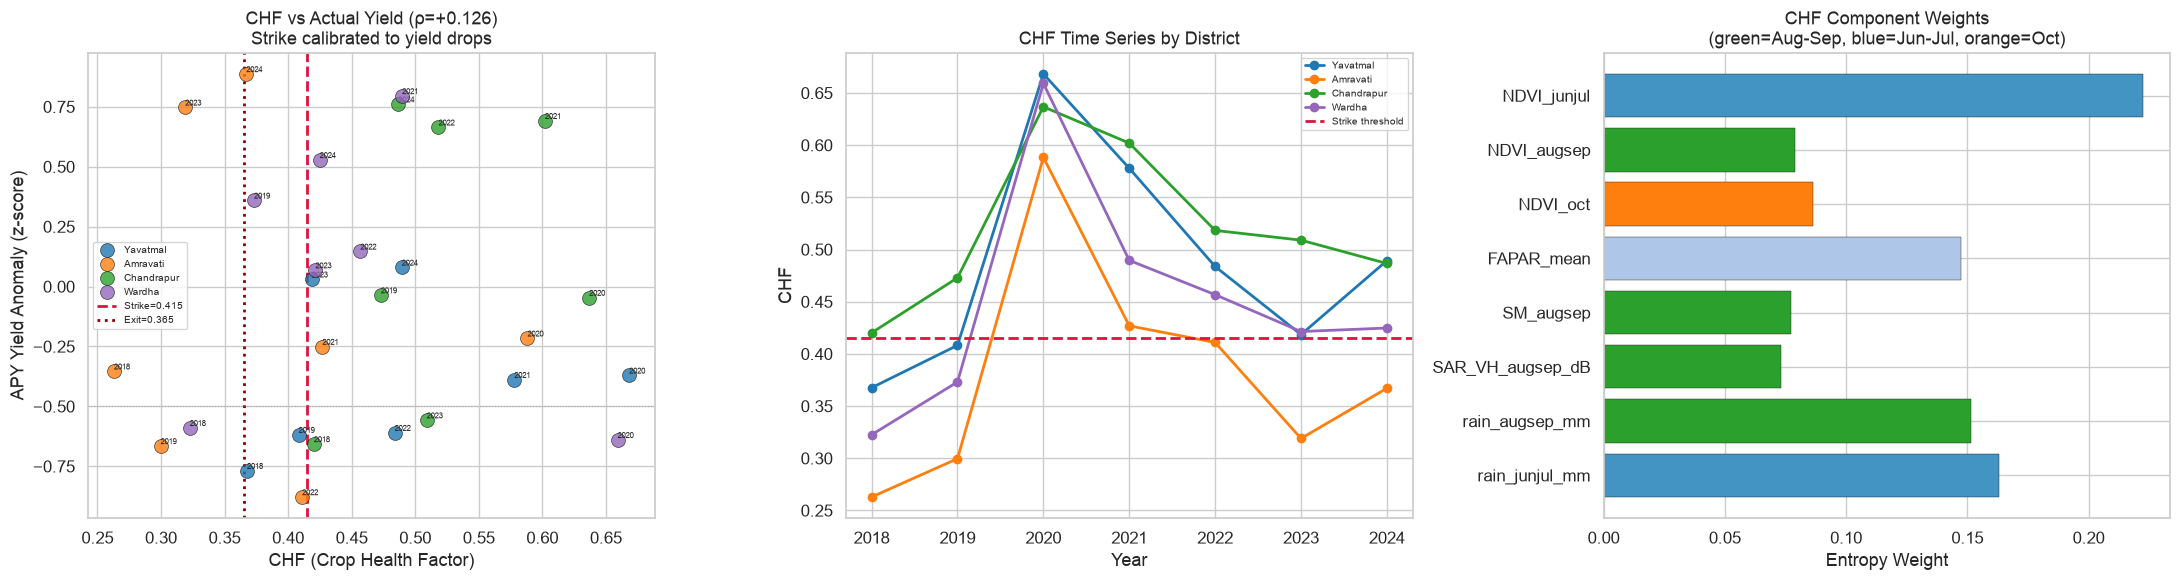

Saved → vidarbha_outputs/chf_calibration_v7.png


In [4]:
# ── CHF vs APY yield — district-year level calibration ────────────────────────
dist_yr_chf = bt.groupby(['district','year'])['CHF'].mean().reset_index()
dist_yr_chf = dist_yr_chf.merge(
    apy_raw[['year','district','crop_stress_z','cotton_lint_yield_z','soybean_yield_z']],
    on=['district','year'], how='inner'
)

# Also merge PMFBY for comparison
pmfby_dy = bt[bt['rate_total'].notna()].groupby(['district','year'])['rate_total'].mean().reset_index()
dist_yr_chf = dist_yr_chf.merge(pmfby_dy, on=['district','year'], how='left')

print('=== CHF CORRELATION WITH GROUND TRUTH ===')
print(f'District-year observations: {len(dist_yr_chf)}')
print()

# CHF vs APY crop stress
rho_apy, p_apy = spearmanr(dist_yr_chf['CHF'], dist_yr_chf['crop_stress_z'])
print(f'CHF vs APY crop_stress_z:  ρ={rho_apy:+.3f}  p={p_apy:.4f}')

# CHF vs PMFBY
valid_pm = dist_yr_chf.dropna(subset=['rate_total'])
rho_pm, p_pm = spearmanr(valid_pm['CHF'], valid_pm['rate_total'])
print(f'CHF vs PMFBY rate_total:   ρ={rho_pm:+.3f}  p={p_pm:.4f}')

# For reference: best single-feature correlation from v6
print()
print('For comparison — best v6 single-feature correlations with APY:')
print('  VHI_mean:  ρ=-0.29')
print(f'  CHF:       ρ={rho_apy:+.3f}  ← {"IMPROVEMENT" if abs(rho_apy) > 0.29 else "similar/lower"}')

# ── Yield-calibrated threshold ────────────────────────────────────────────────
# Find CHF value that best separates "bad yield years" (crop_stress_z < -0.5)
# from normal/good years. Use ROC-like approach.

bad_mask = dist_yr_chf['crop_stress_z'] < -0.5
n_bad = bad_mask.sum()
print(f'\nBad yield district-years (z < -0.5): {n_bad}/{len(dist_yr_chf)}')

# Sweep CHF thresholds and compute F1
best_f1, best_thr = 0, 0
results = []
for thr in np.arange(0.30, 0.60, 0.005):
    pred_bad = dist_yr_chf['CHF'] < thr
    tp = (pred_bad & bad_mask).sum()
    fp = (pred_bad & ~bad_mask).sum()
    fn = (~pred_bad & bad_mask).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    results.append((thr, prec, rec, f1, tp, fp, fn))
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

CHF_STRIKE = best_thr
print(f'\nOptimal CHF threshold (max F1 on APY bad years):')
print(f'  Strike = {CHF_STRIKE:.3f}  (CHF below this → trigger)')
print(f'  F1 = {best_f1:.2f}')

# Also set exit for tiered payout
# Exit = where yields are catastrophically bad (z < -1.0)
catastrophic = dist_yr_chf['crop_stress_z'] < -1.0
if catastrophic.sum() > 0:
    CHF_EXIT = dist_yr_chf.loc[catastrophic, 'CHF'].mean()
else:
    CHF_EXIT = CHF_STRIKE - 0.05
print(f'  Exit  = {CHF_EXIT:.3f}  (max payout below this)')

# ── Flood threshold: sub-window rainfall ──────────────────────────────────────
# Aug-Sep excess rainfall: use per-district IMD standard
print()
print('FLOOD: Rain_augsep > 60% of kharif LPA (per-district IMD excess)')
for dist, lpa in DISTRICT_LPA.items():
    flood_thr = lpa * 0.60  # Aug-Sep is ~60% of kharif
    excess_thr = flood_thr * 1.20
    print(f'  {dist:12s}: augsep_normal={flood_thr:.0f}mm  excess>{excess_thr:.0f}mm')

# ── Visualization ─────────────────────────────────────────────────────────────
DIST_COLORS = {'Yavatmal': '#1f77b4', 'Amravati': '#ff7f0e',
               'Chandrapur': '#2ca02c', 'Wardha': '#9467bd'}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Panel 1: CHF vs APY yield anomaly
ax = axes[0]
for dist, color in DIST_COLORS.items():
    sub = dist_yr_chf[dist_yr_chf['district']==dist]
    ax.scatter(sub['CHF'], sub['crop_stress_z'], c=color, s=100, alpha=0.8,
               edgecolors='k', lw=0.5, label=dist, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(str(int(row['year'])), (row['CHF'], row['crop_stress_z']),
                    fontsize=6, ha='left', va='bottom')
ax.axvline(CHF_STRIKE, color='crimson', ls='--', lw=2, label=f'Strike={CHF_STRIKE:.3f}')
ax.axvline(CHF_EXIT, color='darkred', ls=':', lw=2, label=f'Exit={CHF_EXIT:.3f}')
ax.axhline(-0.5, color='grey', ls=':', lw=0.8, alpha=0.5)
ax.set_xlabel('CHF (Crop Health Factor)')
ax.set_ylabel('APY Yield Anomaly (z-score)')
ax.set_title(f'CHF vs Actual Yield (ρ={rho_apy:+.3f})\nStrike calibrated to yield drops')
ax.legend(fontsize=7)

# Panel 2: CHF time series by district
ax = axes[1]
for dist, color in DIST_COLORS.items():
    sub = dist_yr_chf[dist_yr_chf['district']==dist].sort_values('year')
    ax.plot(sub['year'], sub['CHF'], '-o', color=color, label=dist, lw=2, markersize=6)
ax.axhline(CHF_STRIKE, color='crimson', ls='--', lw=2, label='Strike threshold')
ax.set_xlabel('Year')
ax.set_ylabel('CHF')
ax.set_title('CHF Time Series by District')
ax.legend(fontsize=7)

# Panel 3: Entropy weights bar chart
ax = axes[2]
labels = [c.replace('_norm','') for c in entropy_weights.keys()]
weights = list(entropy_weights.values())
colors = ['#2ca02c' if 'augsep' in l else '#4393c3' if 'junjul' in l
          else '#ff7f0e' if 'oct' in l else '#aec7e8' for l in labels]
ax.barh(labels, weights, color=colors, edgecolor='k', lw=0.3)
ax.set_xlabel('Entropy Weight')
ax.set_title('CHF Component Weights\n(green=Aug-Sep, blue=Jun-Jul, orange=Oct)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUT / 'chf_calibration_v7.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → vidarbha_outputs/chf_calibration_v7.png')

## C · CHF Trigger + Tiered Payout

In [5]:
# ── CHF-based triggers ────────────────────────────────────────────────────────
# Drought: CHF < strike (composite crop health below calibrated threshold)
# Flood: Aug-Sep rainfall > per-district excess (IMD 120% of sub-season LPA)

def apply_triggers_v7(d, chf_strike, chf_exit, district_lpa):
    d = d.copy()

    # Drought trigger: CHF below yield-calibrated strike
    d['trigger_drought'] = d['CHF'] < chf_strike

    # Flood trigger: Aug-Sep rain > 120% of sub-season LPA
    # Aug-Sep is roughly 55-60% of total kharif rainfall
    def flood_check(row):
        lpa = district_lpa.get(row.get('district', 'Yavatmal'), 950)
        augsep_lpa = lpa * 0.58  # Aug-Sep share of kharif
        return row['rain_augsep_mm'] > augsep_lpa * 1.20
    d['trigger_flood'] = d.apply(flood_check, axis=1)

    d['trigger_any'] = d['trigger_drought'] | d['trigger_flood']

    # Drought payout: linear between strike and exit
    def drought_payout(row):
        if not row['trigger_drought']:
            return 0.0
        chf = row['CHF']
        if chf >= chf_strike:
            return 0.0
        elif chf <= chf_exit:
            return 0.25  # cap at 25%
        else:
            return 0.05 + (chf_strike - chf) / (chf_strike - chf_exit) * 0.20

    # Flood payout: linear based on excess rainfall
    def flood_payout(row):
        if not row['trigger_flood']:
            return 0.0
        lpa = district_lpa.get(row.get('district', 'Yavatmal'), 950)
        augsep_lpa = lpa * 0.58
        pct = row['rain_augsep_mm'] / augsep_lpa
        if pct <= 1.20:
            return 0.0
        elif pct <= 1.50:
            return 0.05 + (pct - 1.20) / 0.30 * 0.10
        elif pct <= 1.80:
            return 0.15 + (pct - 1.50) / 0.30 * 0.10
        else:
            return 0.25

    d['payout_drought_pct'] = d.apply(drought_payout, axis=1)
    d['payout_flood_pct']   = d.apply(flood_payout, axis=1)
    d['payout_total_pct']   = d[['payout_drought_pct','payout_flood_pct']].max(axis=1)
    d['payout_rs_per_ha']   = d['payout_total_pct'] * SUM_INSURED_PER_HA

    return d


bt = apply_triggers_v7(bt, CHF_STRIKE, CHF_EXIT, DISTRICT_LPA)
nc = apply_triggers_v7(nc, CHF_STRIKE, CHF_EXIT, DISTRICT_LPA)

print('=== TRIGGER ACTIVATION RATES (v7: CHF composite + flood) ===')
print(f'{"":35s} {"Overall":>8s}  ', end='')
for yr in BACKTEST_YEARS:
    print(f'{str(yr):>8s}', end='')
print()

for col, label in [
    ('trigger_drought', f'Drought (CHF < {CHF_STRIKE:.3f})'),
    ('trigger_flood',   'Flood (rain_augsep > 120% LPA)'),
    ('trigger_any',     'ANY trigger → payout'),
]:
    overall = bt[col].mean()
    print(f'{label:35s} {overall:8.0%}  ', end='')
    for yr in BACKTEST_YEARS:
        yr_rate = bt[bt['year']==yr][col].mean()
        print(f'{yr_rate:8.0%}', end='')
    print()

print()
has_pmfby = bt['rate_total'].notna()
print('PMFBY stress rate (>10%):')
overall_pmfby = bt.loc[has_pmfby, 'pmfby_stress'].mean()
print(f'{"PMFBY stress":35s} {overall_pmfby:8.0%}  ', end='')
for yr in BACKTEST_YEARS:
    mask = (bt['year']==yr) & has_pmfby
    v = bt.loc[mask,'pmfby_stress'].mean() if mask.sum() > 0 else 0
    print(f'{v:8.0%}', end='')
print()

print()
print(f'v7 trigger_any fire rate: {bt["trigger_any"].mean():.0%}')

# ── Payout results ────────────────────────────────────────────────────────────
print()
print('=== PAYOUT RESULTS ===')
print(f'Sum insured: ₹{SUM_INSURED_PER_HA:,}/ha')
for yr in BACKTEST_YEARS:
    s = bt[bt['year']==yr]
    triggered = s['trigger_any'].sum()
    avg_payout = s['payout_total_pct'].mean()
    avg_triggered = s.loc[s['trigger_any'], 'payout_total_pct'].mean() if triggered > 0 else 0
    avg_rs = s['payout_rs_per_ha'].mean()
    print(f'  {yr}: {triggered:3d}/{len(s)} triggered | '
          f'avg (all): {avg_payout:.1%} | avg (triggered): {avg_triggered:.1%} | '
          f'₹/ha: {avg_rs:,.0f}')

=== TRIGGER ACTIVATION RATES (v7: CHF composite + flood) ===
                                     Overall      2018    2019    2020    2021    2022    2023    2024
Drought (CHF < 0.415)                    37%       79%     62%      3%     14%     25%     46%     30%
Flood (rain_augsep > 120% LPA)           13%        0%     57%      8%      1%     23%      1%      2%
ANY trigger → payout                     47%       79%     93%     11%     16%     47%     47%     32%

PMFBY stress rate (>10%):
PMFBY stress                             39%        0%     75%     23%     34%     78%     38%      3%

v7 trigger_any fire rate: 47%

=== PAYOUT RESULTS ===
Sum insured: ₹40,000/ha
  2018: 220/277 triggered | avg (all): 18.1% | avg (triggered): 22.8% | ₹/ha: 7,254
  2019: 258/277 triggered | avg (all): 18.2% | avg (triggered): 19.5% | ₹/ha: 7,277
  2020:  31/277 triggered | avg (all): 1.2% | avg (triggered): 10.9% | ₹/ha: 490
  2021:  44/277 triggered | avg (all): 3.2% | avg (triggered): 20.4% 

## D · Backtest vs PMFBY — Coverage Analysis (v7)

=== BACKTEST COVERAGE ANALYSIS (v7 — CHF) ===
Total RC×year obs (with PMFBY data): 1119

  Aligned (both)           :  202 / 1119 (18.1%)
  Our value-add            :  240 / 1119 (21.4%)
  Our basis risk           :  236 / 1119 (21.1%)
  Quiet (neither)          :  441 / 1119 (39.4%)

Recall on PMFBY events: 202/438 (46%)
Our value-add: 240 RC-years we pay but PMFBY didn't
Our basis risk: 236 RC-years PMFBY paid but we didn't

  Year    PMFBY     Ours  Aligned    V-add   B-risk
  2018        0       46        0       46        0
  2019      129      154      114       40       15
  2020       40       22       12       10       28
  2021       61       14        2       12       59
  2022      136       66       49       17       87
  2023       67       90       23       67       44
  2024        5       50        2       48        3


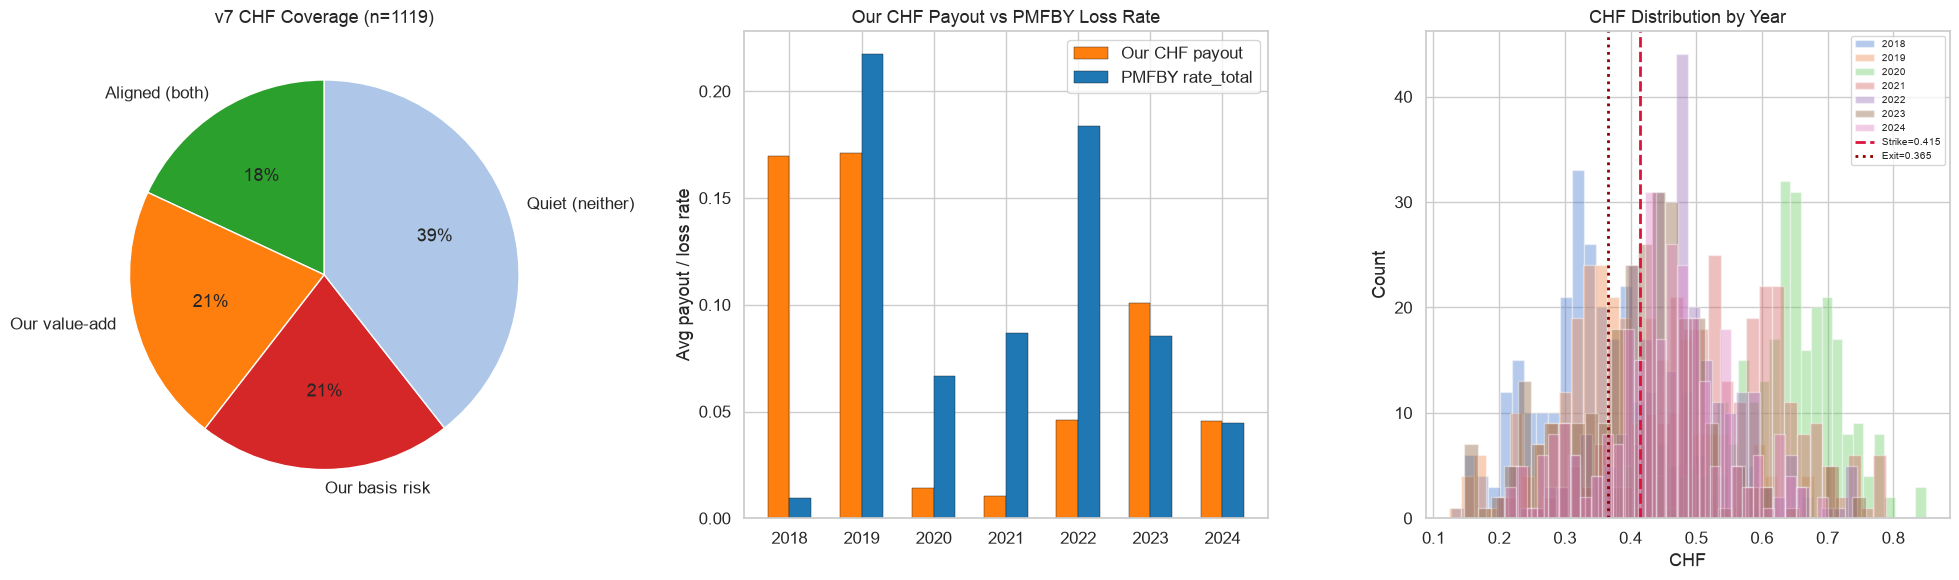

Saved → vidarbha_outputs/chf_backtest_v7.png


In [6]:
# ── Coverage analysis vs PMFBY ────────────────────────────────────────────────
bt_pmfby = bt[bt['rate_total'].notna()].copy()

def categorise(row):
    we   = row['trigger_any']
    them = row['pmfby_stress']
    if     we and     them: return 'Aligned (both)',    '#2ca02c'
    if     we and not them: return 'Our value-add',     '#ff7f0e'
    if not we and     them: return 'Our basis risk',    '#d62728'
    return                         'Quiet (neither)',   '#aec7e8'

cats = bt_pmfby.apply(categorise, axis=1)
bt_pmfby['category'] = [c[0] for c in cats]
cat_counts = bt_pmfby['category'].value_counts()
total = len(bt_pmfby)

print('=== BACKTEST COVERAGE ANALYSIS (v7 — CHF) ===')
print(f'Total RC×year obs (with PMFBY data): {total}')
print()
for cat in ['Aligned (both)', 'Our value-add', 'Our basis risk', 'Quiet (neither)']:
    n = cat_counts.get(cat, 0)
    print(f'  {cat:25s}: {n:4d} / {total} ({n/total:.1%})')

pmfby_events = bt_pmfby['pmfby_stress'].sum()
aligned = cat_counts.get('Aligned (both)', 0)
basis_risk = cat_counts.get('Our basis risk', 0)
value_add = cat_counts.get('Our value-add', 0)
our_triggers = aligned + value_add

print(f'\nRecall on PMFBY events: {aligned}/{int(pmfby_events)} ({aligned/pmfby_events:.0%})')
print(f'Our value-add: {value_add} RC-years we pay but PMFBY didn\'t')
print(f'Our basis risk: {basis_risk} RC-years PMFBY paid but we didn\'t')

# ── Year-by-year breakdown ────────────────────────────────────────────────────
print()
print(f'{"Year":>6s} {"PMFBY":>8s} {"Ours":>8s} {"Aligned":>8s} {"V-add":>8s} {"B-risk":>8s}')
for yr in BACKTEST_YEARS:
    s = bt_pmfby[bt_pmfby['year']==yr]
    pe = int(s['pmfby_stress'].sum())
    ot = int(s['trigger_any'].sum())
    al = int((s['category']=='Aligned (both)').sum())
    va = int((s['category']=='Our value-add').sum())
    br = int((s['category']=='Our basis risk').sum())
    print(f'{yr:>6d} {pe:>8d} {ot:>8d} {al:>8d} {va:>8d} {br:>8d}')

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: coverage pie
ax = axes[0]
cat_order = ['Aligned (both)', 'Our value-add', 'Our basis risk', 'Quiet (neither)']
cat_colors_map = {'Aligned (both)': '#2ca02c', 'Our value-add': '#ff7f0e',
                  'Our basis risk': '#d62728', 'Quiet (neither)': '#aec7e8'}
sizes = [cat_counts.get(c, 0) for c in cat_order]
ax.pie(sizes, labels=cat_order, colors=[cat_colors_map[c] for c in cat_order],
       autopct='%1.0f%%', startangle=90)
ax.set_title(f'v7 CHF Coverage (n={total})')

# Panel 2: our payout vs PMFBY by year
ax = axes[1]
yr_ours  = bt_pmfby.groupby('year')['payout_total_pct'].mean()
yr_pmfby = bt_pmfby.groupby('year')['rate_total'].mean()
x = np.arange(len(BACKTEST_YEARS))
ax.bar(x - 0.15, [yr_ours.get(y, 0) for y in BACKTEST_YEARS], 0.3,
       label='Our CHF payout', color='#ff7f0e', edgecolor='k', lw=0.3)
ax.bar(x + 0.15, [yr_pmfby.get(y, 0) for y in BACKTEST_YEARS], 0.3,
       label='PMFBY rate_total', color='#1f77b4', edgecolor='k', lw=0.3)
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in BACKTEST_YEARS])
ax.set_ylabel('Avg payout / loss rate')
ax.set_title('Our CHF Payout vs PMFBY Loss Rate')
ax.legend()

# Panel 3: CHF distribution with threshold
ax = axes[2]
for yr in BACKTEST_YEARS:
    yr_chf_vals = bt[bt['year']==yr]['CHF']
    ax.hist(yr_chf_vals, bins=30, alpha=0.4, label=str(yr))
ax.axvline(CHF_STRIKE, color='crimson', lw=2, ls='--', label=f'Strike={CHF_STRIKE:.3f}')
ax.axvline(CHF_EXIT, color='darkred', lw=2, ls=':', label=f'Exit={CHF_EXIT:.3f}')
ax.set_xlabel('CHF')
ax.set_ylabel('Count')
ax.set_title('CHF Distribution by Year')
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(OUT / 'chf_backtest_v7.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → vidarbha_outputs/chf_backtest_v7.png')

## E · 2025 Nowcast

In [7]:
# ── 2025 Nowcast ──────────────────────────────────────────────────────────────
print('=== 2025 NOWCAST (v7 — CHF) ===')
print(f'CHF Strike: {CHF_STRIKE:.3f}  |  Exit: {CHF_EXIT:.3f}')
print()

for col, label in [
    ('trigger_drought', f'Drought (CHF < {CHF_STRIKE:.3f})'),
    ('trigger_flood',   'Flood (rain_augsep excess)'),
    ('trigger_any',     'ANY → payout'),
]:
    n = nc[col].sum()
    pct = nc[col].mean()
    print(f'  {label:35s}: {n:3d} / {len(nc)} RCs ({pct:.0%})')

print()
print('2025 by district:')
for dist in sorted(nc['district'].unique()):
    d = nc[nc['district']==dist]
    lpa = DISTRICT_LPA.get(dist, 950)
    chf_mean = d['CHF'].mean()
    rain_as = d['rain_augsep_mm'].mean()
    print(f'  {dist} (LPA={lpa}mm): CHF={chf_mean:.3f} | '
          f'rain_as={rain_as:.0f}mm | '
          f'{d["trigger_drought"].sum()}/{len(d)} drought | '
          f'{d["trigger_flood"].sum()}/{len(d)} flood | '
          f'{d["trigger_any"].sum()}/{len(d)} any')

triggered_nc = nc[nc['trigger_any']]
if len(triggered_nc) > 0:
    avg_payout = triggered_nc['payout_total_pct'].mean()
    max_payout = triggered_nc['payout_total_pct'].max()
    print(f'\nTriggered RCs: avg payout = {avg_payout:.1%} | max = {max_payout:.1%}')
    print(f'  = ₹{avg_payout * SUM_INSURED_PER_HA:,.0f}/ha avg | ₹{max_payout * SUM_INSURED_PER_HA:,.0f}/ha max')

# ── v5 vs v7 comparison table ─────────────────────────────────────────────────
print()
print('=== v5 vs v7 COMPARISON ===')
print(f'{"Metric":35s} {"v5 (rules)":>12s} {"v7 (CHF)":>12s}')
print('-' * 60)
v5_fire = 0.63  # from v5/v6 results
v7_fire = bt['trigger_any'].mean()
print(f'{"Overall fire rate":35s} {"63%":>12s} {v7_fire:>11.0%}')
print(f'{"Basis risk (PMFBY miss)":35s} {"12.5%":>12s} {basis_risk/total:>11.1%}')
print(f'{"Value-add":35s} {"32.0%":>12s} {value_add/total:>11.1%}')
print(f'{"PMFBY recall":35s} {"68%":>12s} {aligned/pmfby_events:>11.0%}')
print(f'{"CHF-APY correlation (ρ)":35s} {"–0.29*":>12s} {rho_apy:>+11.3f}')
print(f'{"Threshold source":35s} {"percentile":>12s} {"yield-calib":>12s}')

=== 2025 NOWCAST (v7 — CHF) ===
CHF Strike: 0.415  |  Exit: 0.365

  Drought (CHF < 0.415)              :  37 / 277 RCs (13%)
  Flood (rain_augsep excess)         : 127 / 277 RCs (46%)
  ANY → payout                       : 161 / 277 RCs (58%)

2025 by district:
  Amravati (LPA=850.0mm): CHF=0.445 | rain_as=484mm | 33/88 drought | 5/88 flood | 38/88 any
  Chandrapur (LPA=1100.0mm): CHF=0.629 | rain_as=798mm | 1/71 drought | 47/71 flood | 48/71 any
  Wardha (LPA=860.0mm): CHF=0.506 | rain_as=558mm | 0/8 drought | 2/8 flood | 2/8 any
  Yavatmal (LPA=950.0mm): CHF=0.584 | rain_as=686mm | 3/110 drought | 73/110 flood | 73/110 any

Triggered RCs: avg payout = 11.5% | max = 25.0%
  = ₹4,607/ha avg | ₹10,000/ha max

=== v5 vs v7 COMPARISON ===
Metric                                v5 (rules)     v7 (CHF)
------------------------------------------------------------
Overall fire rate                            63%         47%
Basis risk (PMFBY miss)                    12.5%       21.1%
Value-ad